In [2]:
# I load the dataset and check its basic structure

import pandas as pd
import numpy as np

# I use r before the path so Windows backslashes work correctly
file_path = r"C:\Users\DELL\Downloads\ai4i+2020+predictive+maintenance+dataset\ai4i2020.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("-" * 60)

print("Shape of the dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nBasic dataset information:")
df.info()

print("\nMissing values in each column:")
print(df.isna().sum())

print("\nNumber of duplicated rows:")
print(df.duplicated().sum())

Dataset loaded successfully.
------------------------------------------------------------
Shape of the dataset:
(10000, 14)

Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Basic dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  


In [3]:
# I clean column names and create a safer working copy

# I make a copy so the original dataset stays unchanged
data = df.copy()

# I clean column names to make coding easier
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)

print("Cleaned column names:")
print(data.columns.tolist())

print("\nFirst 5 rows after column-name cleaning:")
display(data.head())

# I separate identifier columns, target column, and possible leakage columns
id_columns = ["udi", "product_id"]
target_column = "machine_failure"
leakage_columns = ["twf", "hdf", "pwf", "osf", "rnf"]

# These are the genuine input features available before failure is known
feature_columns = [
    col for col in data.columns
    if col not in id_columns + [target_column] + leakage_columns
]

print("\nIdentifier columns removed from modelling:")
print(id_columns)

print("\nLeakage columns excluded from modelling:")
print(leakage_columns)

print("\nFinal feature columns for modelling:")
print(feature_columns)

print("\nTarget column:")
print(target_column)

# I create X and y for later modelling
X_raw = data[feature_columns].copy()
y = data[target_column].copy()

print("\nShape of X_raw:")
print(X_raw.shape)

print("\nShape of y:")
print(y.shape)

print("\nTarget value counts:")
print(y.value_counts())

print("\nTarget value percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Cleaned column names:
['udi', 'product_id', 'type', 'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf']

First 5 rows after column-name cleaning:


,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Identifier columns removed from modelling:
['udi', 'product_id']

Leakage columns excluded from modelling:
['twf', 'hdf', 'pwf', 'osf', 'rnf']

Final feature columns for modelling:
['type', 'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']

Target column:
machine_failure

Shape of X_raw:
(10000, 6)

Shape of y:
(10000,)

Target value counts:
machine_failure
0    9661
1     339
Name: count, dtype: int64

Target value percentages:
machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [4]:
# I create descriptive summary tables for the report

import pandas as pd
import numpy as np

# I separate numerical and categorical columns from the safe modelling features
numeric_features = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_raw.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nDescriptive statistics for numerical features:")
numeric_summary = data[numeric_features].describe().T
numeric_summary["skewness"] = data[numeric_features].skew()
numeric_summary["missing_values"] = data[numeric_features].isna().sum()
display(numeric_summary.round(3))

print("\nProduct type distribution:")
type_summary = (
    data["type"]
    .value_counts()
    .rename_axis("type")
    .reset_index(name="count")
)
type_summary["percentage"] = (type_summary["count"] / len(data) * 100).round(2)
display(type_summary)

print("\nMachine failure distribution:")
target_summary = (
    data["machine_failure"]
    .value_counts()
    .rename_axis("machine_failure")
    .reset_index(name="count")
)
target_summary["percentage"] = (target_summary["count"] / len(data) * 100).round(2)
display(target_summary)

print("\nFailure type counts:")
failure_type_summary = data[leakage_columns].sum().sort_values(ascending=False).reset_index()
failure_type_summary.columns = ["failure_type", "count"]
failure_type_summary["percentage_of_dataset"] = (failure_type_summary["count"] / len(data) * 100).round(2)
display(failure_type_summary)

print("\nMachine failure rate by product type:")
type_failure_rate = (
    data.groupby("type")["machine_failure"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)
type_failure_rate.columns = ["type", "total_records", "failure_count", "failure_rate"]
type_failure_rate["failure_rate_percent"] = (type_failure_rate["failure_rate"] * 100).round(2)
display(type_failure_rate[["type", "total_records", "failure_count", "failure_rate_percent"]])

Numerical features:
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']

Categorical features:
['type']

Descriptive statistics for numerical features:


,count,mean,std,min,25%,50%,75%,max,skewness,missing_values
air_temperature_k,10000.0,300.005,2.000,295.3,298.3,300.1,301.5,304.5,0.114,0
process_temperature_k,10000.0,310.006,1.484,305.7,308.8,310.1,311.1,313.8,0.015,0
rotational_speed_rpm,10000.0,1538.776,179.284,1168.0,1423.0,1503.0,1612.0,2886.0,1.993,0
torque_nm,10000.0,39.987,9.969,3.8,33.2,40.1,46.8,76.6,-0.010,0
tool_wear_min,10000.0,107.951,63.654,0.0,53.0,108.0,162.0,253.0,0.027,0



Product type distribution:


,type,count,percentage
0,L,6000,60.00
1,M,2997,29.97
2,H,1003,10.03



Machine failure distribution:


,machine_failure,count,percentage
0,0,9661,96.61
1,1,339,3.39



Failure type counts:


,failure_type,count,percentage_of_dataset
0,hdf,115,1.15
1,osf,98,0.98
2,pwf,95,0.95
3,twf,46,0.46
4,rnf,19,0.19



Machine failure rate by product type:


,type,total_records,failure_count,failure_rate_percent
0,H,1003,21,2.09
1,L,6000,235,3.92
2,M,2997,83,2.77


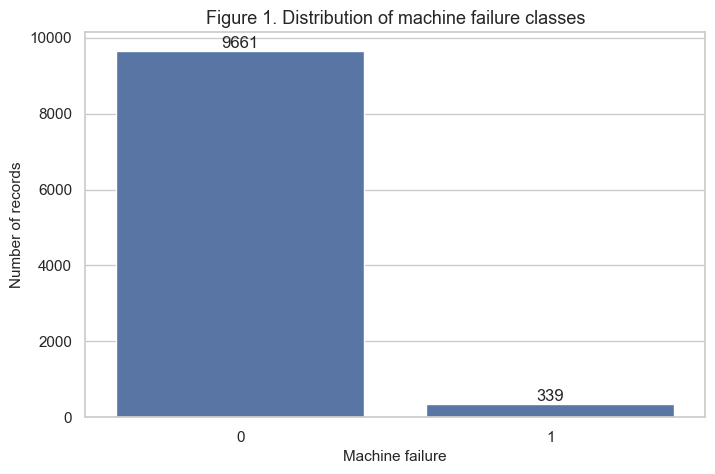

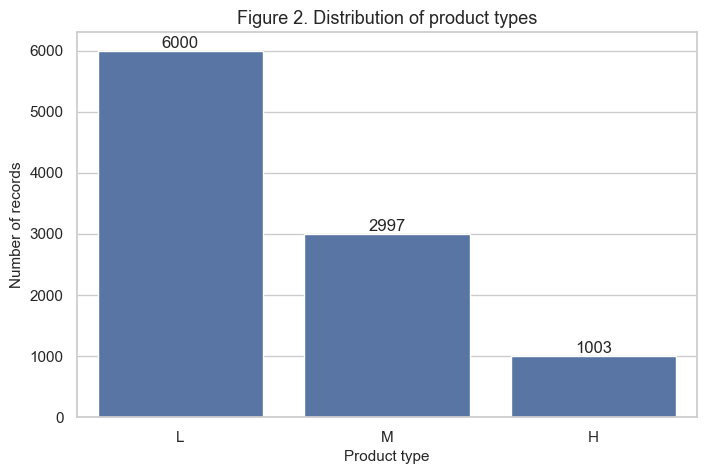

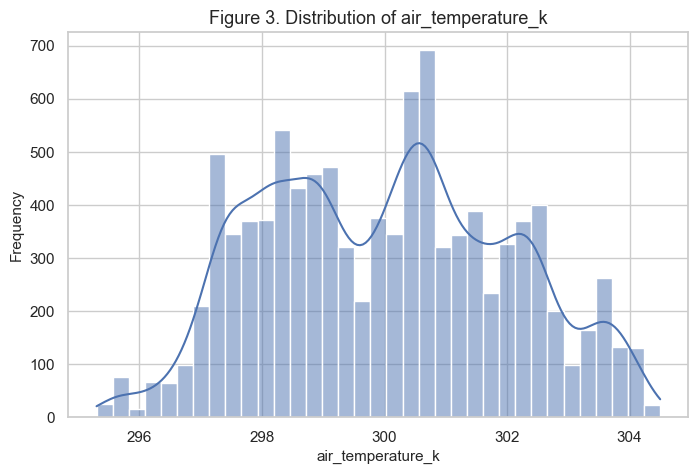

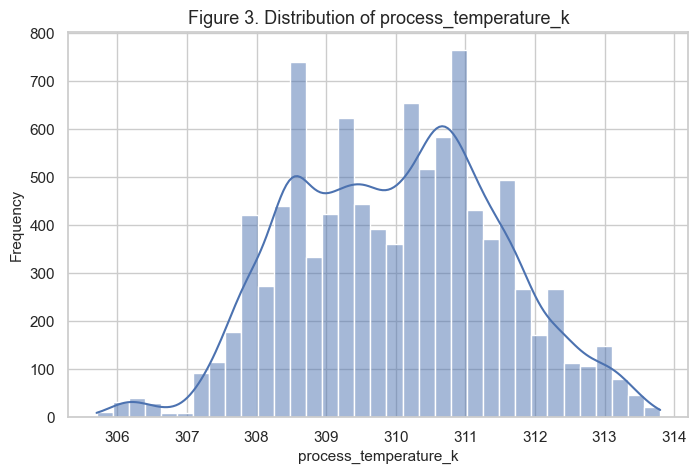

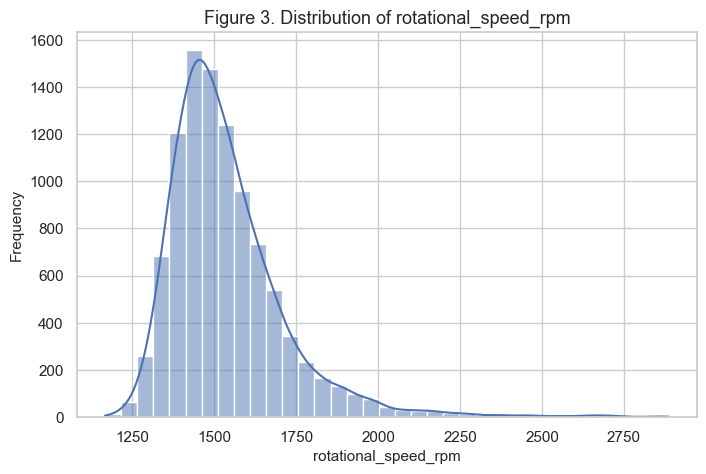

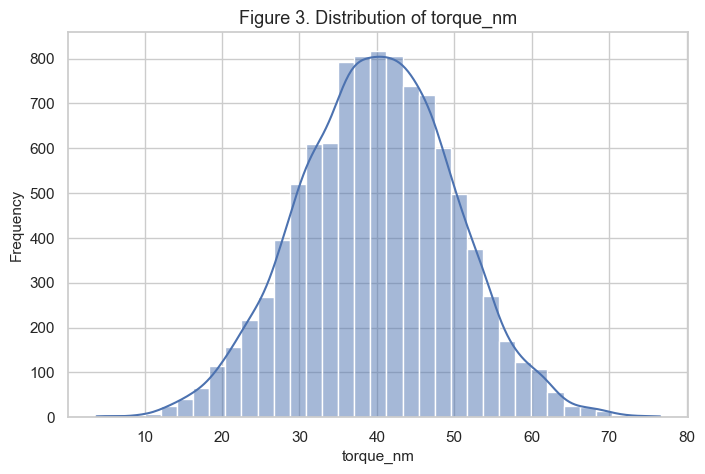

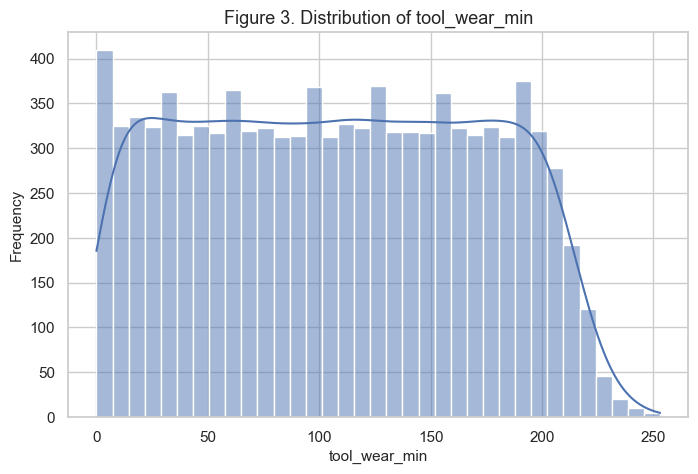

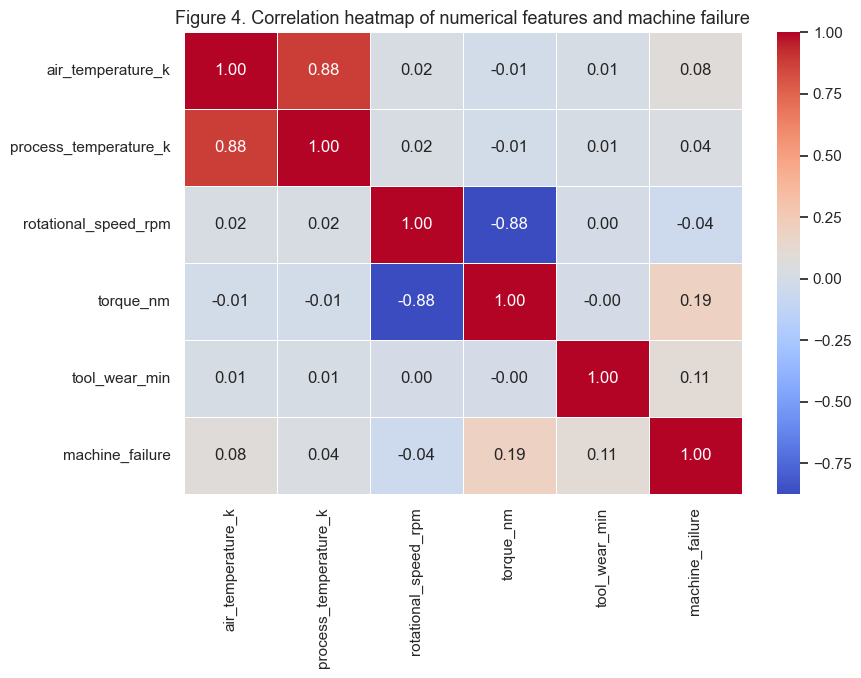

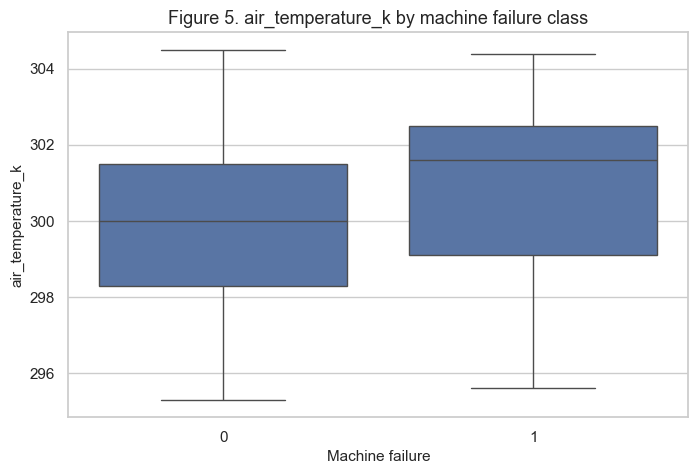

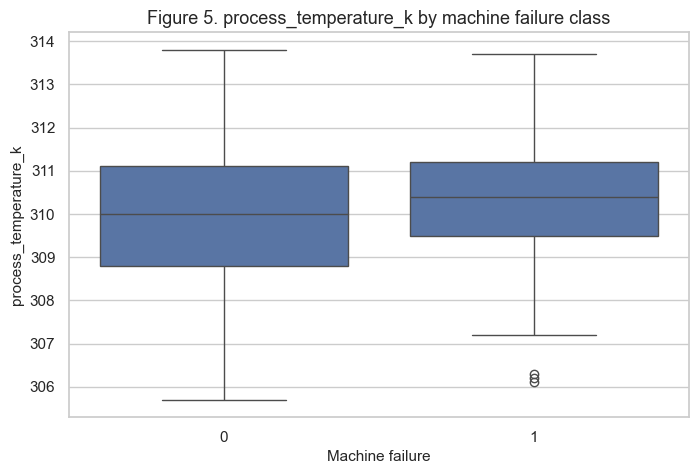

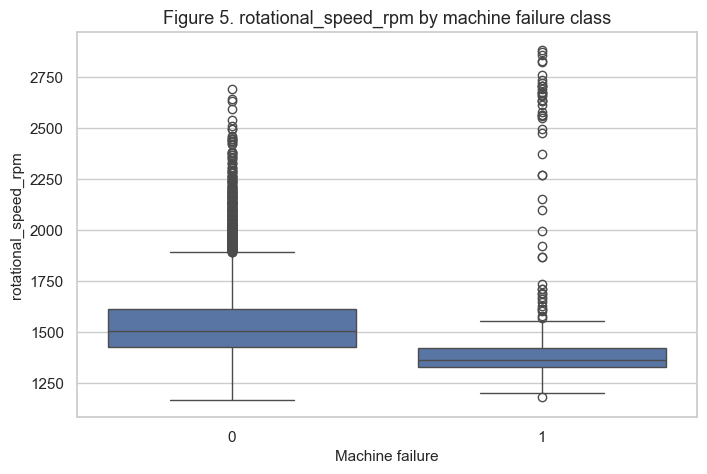

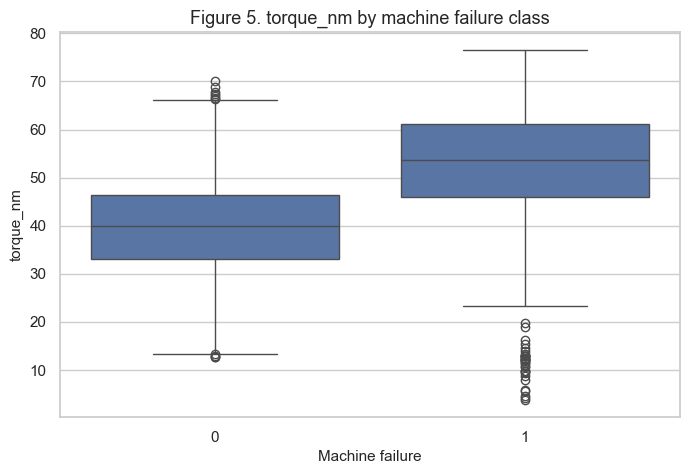

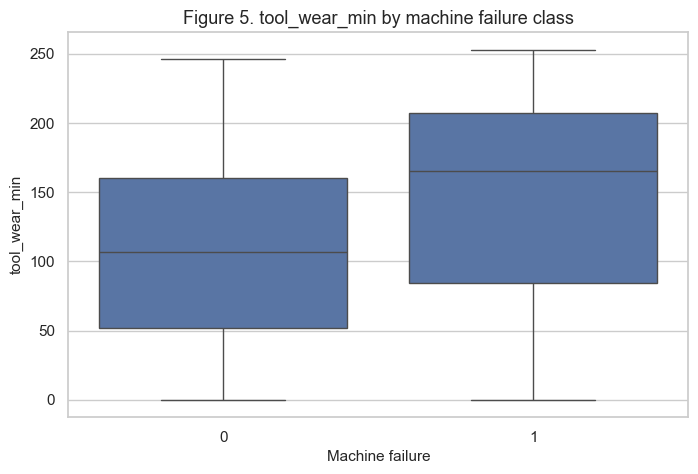

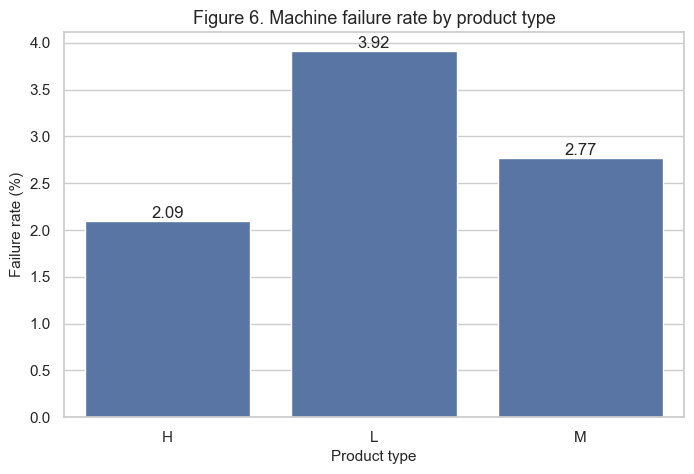

In [5]:
# I create EDA figures for the report

import matplotlib.pyplot as plt
import seaborn as sns

# I set a clean visual style for readable report figures
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Figure 1: Machine failure class distribution
plt.figure()
ax = sns.countplot(data=data, x="machine_failure")
plt.title("Figure 1. Distribution of machine failure classes")
plt.xlabel("Machine failure")
plt.ylabel("Number of records")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


# Figure 2: Product type distribution
plt.figure()
ax = sns.countplot(data=data, x="type", order=data["type"].value_counts().index)
plt.title("Figure 2. Distribution of product types")
plt.xlabel("Product type")
plt.ylabel("Number of records")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


# Figure 3: Numerical feature distributions
for col in numeric_features:
    plt.figure()
    sns.histplot(data=data, x=col, kde=True, bins=35)
    plt.title(f"Figure 3. Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


# Figure 4: Correlation heatmap for numerical features and target
corr_cols = numeric_features + [target_column]

plt.figure(figsize=(9, 6))
sns.heatmap(
    data[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Figure 4. Correlation heatmap of numerical features and machine failure")
plt.show()


# Figure 5: Boxplots of numerical features by machine failure
for col in numeric_features:
    plt.figure()
    sns.boxplot(data=data, x="machine_failure", y=col)
    plt.title(f"Figure 5. {col} by machine failure class")
    plt.xlabel("Machine failure")
    plt.ylabel(col)
    plt.show()


# Figure 6: Machine failure rate by product type
type_failure_plot = (
    data.groupby("type")["machine_failure"]
    .mean()
    .reset_index()
)
type_failure_plot["failure_rate_percent"] = type_failure_plot["machine_failure"] * 100

plt.figure()
ax = sns.barplot(data=type_failure_plot, x="type", y="failure_rate_percent")
plt.title("Figure 6. Machine failure rate by product type")
plt.xlabel("Product type")
plt.ylabel("Failure rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

In [6]:
# I prepare the train-test split and preprocessing pipeline

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# I split the data before any model training to avoid test-set leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:")
print(X_train.shape)

print("\nTesting feature shape:")
print(X_test.shape)

print("\nTraining target distribution:")
train_dist = y_train.value_counts().rename_axis("machine_failure").reset_index(name="count")
train_dist["percentage"] = (train_dist["count"] / len(y_train) * 100).round(2)
display(train_dist)

print("\nTesting target distribution:")
test_dist = y_test.value_counts().rename_axis("machine_failure").reset_index(name="count")
test_dist["percentage"] = (test_dist["count"] / len(y_test) * 100).round(2)
display(test_dist)

# I define preprocessing separately for numerical and categorical features
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("\nNumerical features to scale:")
print(numeric_features)

print("\nCategorical features to encode:")
print(categorical_features)

print("\nPreprocessing pipeline created successfully.")

Training feature shape:
(8000, 6)

Testing feature shape:
(2000, 6)

Training target distribution:


,machine_failure,count,percentage
0,0,7729,96.61
1,1,271,3.39



Testing target distribution:


,machine_failure,count,percentage
0,0,1932,96.6
1,1,68,3.4



Numerical features to scale:
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']

Categorical features to encode:
['type']

Preprocessing pipeline created successfully.


In [7]:
# I train baseline models and compare them with proper classification metrics

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# I define a helper function so every model is evaluated in the same way
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None
    
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0)
    }
    
    if y_prob is not None:
        results["roc_auc"] = roc_auc_score(y_test, y_prob)
        results["pr_auc"] = average_precision_score(y_test, y_prob)
    else:
        results["roc_auc"] = np.nan
        results["pr_auc"] = np.nan
    
    return results


# I start with sensible baseline models
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

baseline_results = []
trained_baseline_models = {}

for model_name, estimator in baseline_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])
    
    pipe.fit(X_train, y_train)
    trained_baseline_models[model_name] = pipe
    
    result = evaluate_model(model_name, pipe, X_test, y_test)
    baseline_results.append(result)

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df.sort_values(by="f1_score", ascending=False)

print("Baseline model performance on the untouched test set:")
display(baseline_results_df.round(4))

print("\nDetailed classification reports:")
for model_name, model in trained_baseline_models.items():
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=0))

Baseline model performance on the untouched test set:


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
3,Gradient Boosting,0.9860,0.8846,0.6765,0.7667,0.9699,0.8022
2,Random Forest,0.9840,0.9286,0.5735,0.7091,0.9604,0.8069
1,Decision Tree,0.9780,0.6818,0.6618,0.6716,0.8254,0.4627
0,Logistic Regression,0.9675,0.6364,0.1029,0.1772,0.8995,0.4215



Detailed classification reports:

Logistic Regression
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000


Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.68      0.66      0.67        68

    accuracy                           0.98      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.98      0.98      0.98      2000


Random Forest
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.93      0.57      0.71        68

    accuracy                           0.98      2000
   macro avg       0.96      0.79      0.85

In [8]:
# I train balanced models to handle the rare failure class more fairly

from sklearn.utils.class_weight import compute_sample_weight

balanced_models = {
    "Balanced Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Balanced Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    "Balanced Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

balanced_results = []
trained_balanced_models = {}

for model_name, estimator in balanced_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])
    
    pipe.fit(X_train, y_train)
    trained_balanced_models[model_name] = pipe
    
    result = evaluate_model(model_name, pipe, X_test, y_test)
    balanced_results.append(result)


# I handle Gradient Boosting separately using sample weights
gb_balanced_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

gb_balanced_pipe.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)

trained_balanced_models["Weighted Gradient Boosting"] = gb_balanced_pipe
balanced_results.append(
    evaluate_model("Weighted Gradient Boosting", gb_balanced_pipe, X_test, y_test)
)

balanced_results_df = pd.DataFrame(balanced_results)
balanced_results_df = balanced_results_df.sort_values(by="f1_score", ascending=False)

print("Balanced model performance on the untouched test set:")
display(balanced_results_df.round(4))

print("\nBaseline vs balanced model comparison:")
combined_results_df = pd.concat(
    [baseline_results_df, balanced_results_df],
    ignore_index=True
).sort_values(by="f1_score", ascending=False)

display(combined_results_df.round(4))

print("\nDetailed classification reports for balanced models:")
for model_name, model in trained_balanced_models.items():
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=0))

Balanced model performance on the untouched test set:


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
1,Balanced Decision Tree,0.9785,0.7119,0.6176,0.6614,0.8044,0.4527
2,Balanced Random Forest,0.9815,0.9189,0.5000,0.6476,0.9605,0.7963
3,Weighted Gradient Boosting,0.9335,0.3224,0.8676,0.4701,0.9653,0.6623
0,Balanced Logistic Regression,0.8245,0.1418,0.8235,0.2419,0.9069,0.3817



Baseline vs balanced model comparison:


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Gradient Boosting,0.9860,0.8846,0.6765,0.7667,0.9699,0.8022
1,Random Forest,0.9840,0.9286,0.5735,0.7091,0.9604,0.8069
2,Decision Tree,0.9780,0.6818,0.6618,0.6716,0.8254,0.4627
4,Balanced Decision Tree,0.9785,0.7119,0.6176,0.6614,0.8044,0.4527
5,Balanced Random Forest,0.9815,0.9189,0.5000,0.6476,0.9605,0.7963
6,Weighted Gradient Boosting,0.9335,0.3224,0.8676,0.4701,0.9653,0.6623
7,Balanced Logistic Regression,0.8245,0.1418,0.8235,0.2419,0.9069,0.3817
3,Logistic Regression,0.9675,0.6364,0.1029,0.1772,0.8995,0.4215



Detailed classification reports for balanced models:

Balanced Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000


Balanced Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.62      0.66        68

    accuracy                           0.98      2000
   macro avg       0.85      0.80      0.83      2000
weighted avg       0.98      0.98      0.98      2000


Balanced Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.92      0.50      0.65        68

    accuracy                           0.98      2

In [9]:
# I tune the strongest models using cross-validation

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# I use stratified folds because the failure class is rare
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Random Forest tuning
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

print("Tuning Random Forest...")
rf_grid.fit(X_train, y_train)

print("\nBest Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest cross-validation F1-score:")
print(round(rf_grid.best_score_, 4))


# Gradient Boosting tuning
gb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 3],
    "model__subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    estimator=gb_pipe,
    param_grid=gb_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

print("\nTuning Gradient Boosting...")
gb_grid.fit(X_train, y_train)

print("\nBest Gradient Boosting parameters:")
print(gb_grid.best_params_)

print("\nBest Gradient Boosting cross-validation F1-score:")
print(round(gb_grid.best_score_, 4))


# I evaluate both tuned models on the untouched test set
tuned_models = {
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Gradient Boosting": gb_grid.best_estimator_
}

tuned_results = []

for model_name, model in tuned_models.items():
    tuned_results.append(evaluate_model(model_name, model, X_test, y_test))

tuned_results_df = pd.DataFrame(tuned_results).sort_values(by="f1_score", ascending=False)

print("\nTuned model performance on the untouched test set:")
display(tuned_results_df.round(4))

print("\nAll model comparison after tuning:")
all_results_df = pd.concat(
    [combined_results_df, tuned_results_df],
    ignore_index=True
).sort_values(by="f1_score", ascending=False)

display(all_results_df.round(4))

Tuning Random Forest...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Random Forest parameters:
{'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 400}

Best Random Forest cross-validation F1-score:
0.66

Tuning Gradient Boosting...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__n_estimators': 200, 'model__subsample': 1.0}

Best Gradient Boosting cross-validation F1-score:
0.74

Tuned model performance on the untouched test set:


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
1,Tuned Gradient Boosting,0.9865,0.8475,0.7353,0.7874,0.9692,0.8066
0,Tuned Random Forest,0.9820,0.7857,0.6471,0.7097,0.9651,0.7708



All model comparison after tuning:


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
8,Tuned Gradient Boosting,0.9865,0.8475,0.7353,0.7874,0.9692,0.8066
0,Gradient Boosting,0.9860,0.8846,0.6765,0.7667,0.9699,0.8022
9,Tuned Random Forest,0.9820,0.7857,0.6471,0.7097,0.9651,0.7708
1,Random Forest,0.9840,0.9286,0.5735,0.7091,0.9604,0.8069
2,Decision Tree,0.9780,0.6818,0.6618,0.6716,0.8254,0.4627
3,Balanced Decision Tree,0.9785,0.7119,0.6176,0.6614,0.8044,0.4527
4,Balanced Random Forest,0.9815,0.9189,0.5000,0.6476,0.9605,0.7963
5,Weighted Gradient Boosting,0.9335,0.3224,0.8676,0.4701,0.9653,0.6623
6,Balanced Logistic Regression,0.8245,0.1418,0.8235,0.2419,0.9069,0.3817
7,Logistic Regression,0.9675,0.6364,0.1029,0.1772,0.8995,0.4215


Final selected model:
Tuned Gradient Boosting

Final model classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.85      0.74      0.79        68

    accuracy                           0.99      2000
   macro avg       0.92      0.87      0.89      2000
weighted avg       0.99      0.99      0.99      2000


Final model confusion matrix values:
[[1923    9]
 [  18   50]]


,Metric,Value
0,True negatives,1923
1,False positives,9
2,False negatives,18
3,True positives,50
4,Failure cases correctly detected,50
5,Failure cases missed,18


<Figure size 600x500 with 0 Axes>

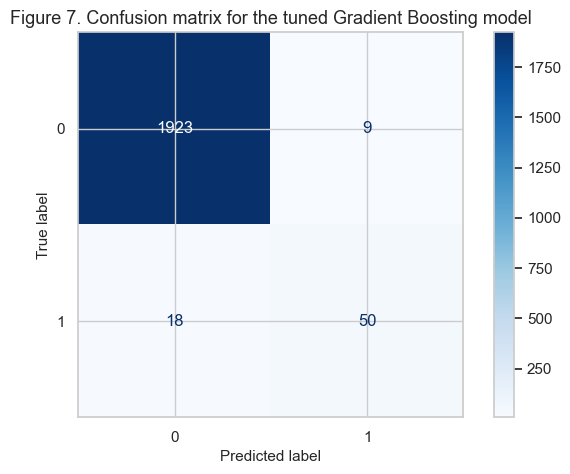

<Figure size 700x500 with 0 Axes>

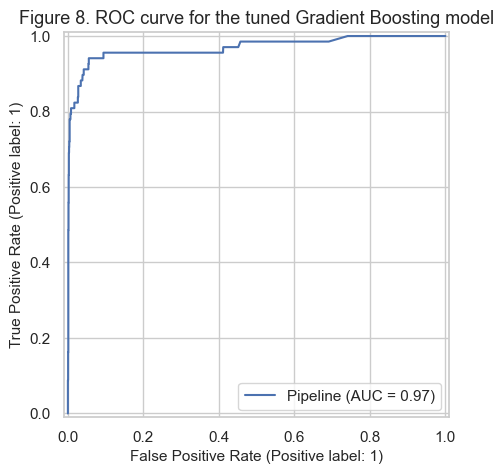

<Figure size 700x500 with 0 Axes>

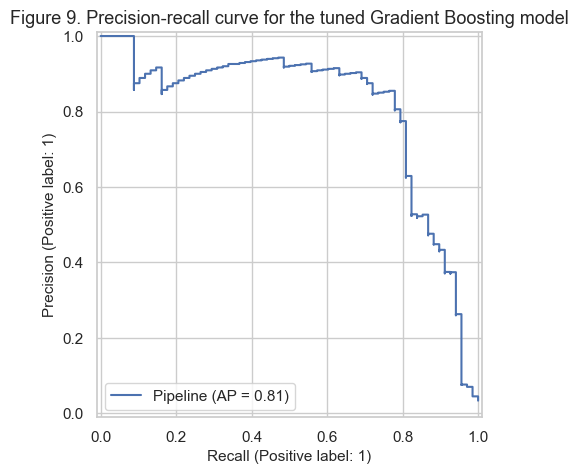

In [10]:
# I create final evaluation figures for the selected model

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# I select the best model based on the tuned test-set F1-score
final_model_name = "Tuned Gradient Boosting"
final_model = gb_grid.best_estimator_

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print("Final selected model:")
print(final_model_name)

print("\nFinal model classification report:")
print(classification_report(y_test, y_pred_final, zero_division=0))

print("\nFinal model confusion matrix values:")
cm = confusion_matrix(y_test, y_pred_final)
print(cm)

tn, fp, fn, tp = cm.ravel()

final_error_summary = pd.DataFrame({
    "Metric": [
        "True negatives",
        "False positives",
        "False negatives",
        "True positives",
        "Failure cases correctly detected",
        "Failure cases missed"
    ],
    "Value": [
        tn,
        fp,
        fn,
        tp,
        tp,
        fn
    ]
})

display(final_error_summary)


# Figure 7: Confusion matrix
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    cmap="Blues",
    values_format="d"
)
plt.title("Figure 7. Confusion matrix for the tuned Gradient Boosting model")
plt.show()


# Figure 8: ROC curve for final model
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Figure 8. ROC curve for the tuned Gradient Boosting model")
plt.show()


# Figure 9: Precision-recall curve for final model
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Figure 9. Precision-recall curve for the tuned Gradient Boosting model")
plt.show()

Feature importance from the tuned Gradient Boosting model:


,feature,importance,importance_percent
3,torque_nm,0.387287,38.73
4,tool_wear_min,0.180790,18.08
2,rotational_speed_rpm,0.165340,16.53
0,air_temperature_k,0.140187,14.02
1,process_temperature_k,0.105729,10.57
5,type_L,0.017268,1.73
6,type_M,0.003398,0.34


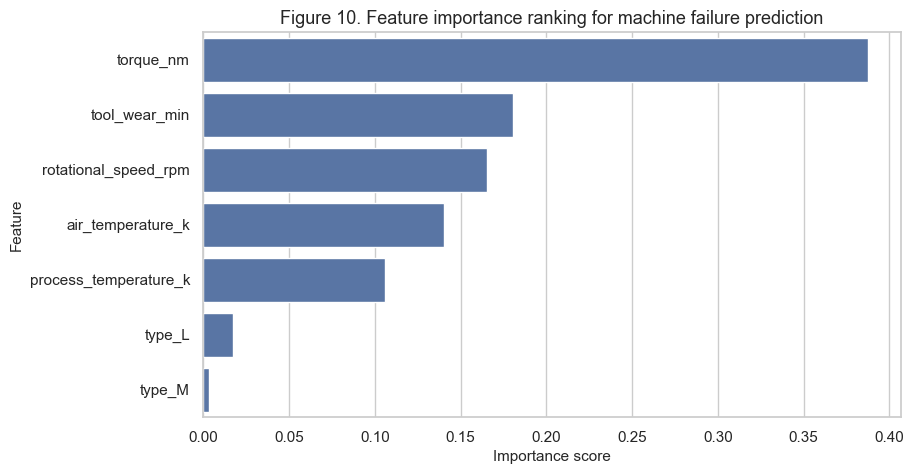

In [11]:
# I extract feature importance from the tuned Gradient Boosting model

# I get the fitted preprocessing step and model step
fitted_preprocessor = final_model.named_steps["preprocessor"]
fitted_gb_model = final_model.named_steps["model"]

# I collect feature names after preprocessing
encoded_cat_features = (
    fitted_preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

final_feature_names = numeric_features + encoded_cat_features

# I create a feature importance table
feature_importance_df = pd.DataFrame({
    "feature": final_feature_names,
    "importance": fitted_gb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_df["importance_percent"] = (
    feature_importance_df["importance"] * 100
).round(2)

print("Feature importance from the tuned Gradient Boosting model:")
display(feature_importance_df)

# Figure 10: Feature importance plot
plt.figure(figsize=(9, 5))
sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature"
)
plt.title("Figure 10. Feature importance ranking for machine failure prediction")
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.show()

Threshold performance table:


,threshold,accuracy,precision,recall,f1_score,false_positives,false_negatives,true_positives
0,0.10,0.9685,0.5229,0.8382,0.6441,52,11,57
1,0.15,0.9750,0.5957,0.8235,0.6914,38,12,56
2,0.20,0.9815,0.6962,0.8088,0.7483,24,13,55
3,0.25,0.9830,0.7237,0.8088,0.7639,21,13,55
4,0.30,0.9855,0.7826,0.7941,0.7883,15,14,54
5,0.35,0.9860,0.8030,0.7794,0.7910,13,15,53
6,0.40,0.9880,0.8548,0.7794,0.8154,9,15,53
7,0.45,0.9870,0.8500,0.7500,0.7969,9,17,51
8,0.50,0.9865,0.8475,0.7353,0.7874,9,18,50
9,0.55,0.9870,0.9038,0.6912,0.7833,5,21,47



Best threshold based on F1-score:


,threshold,accuracy,precision,recall,f1_score,false_positives,false_negatives,true_positives
6,0.4,0.988,0.8548,0.7794,0.8154,9.0,15.0,53.0


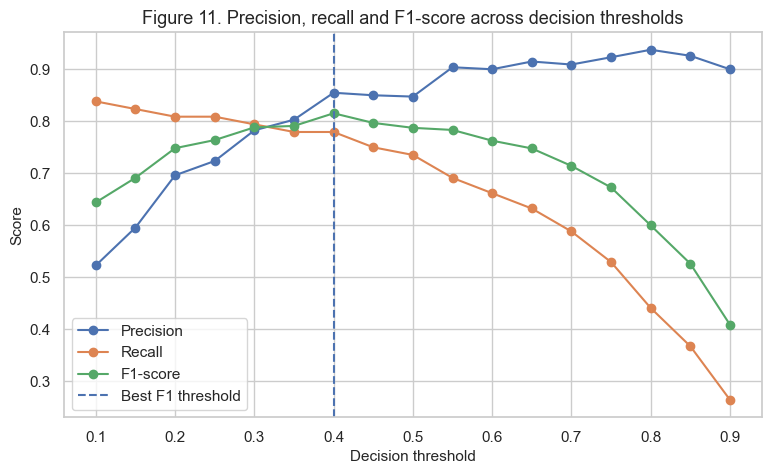

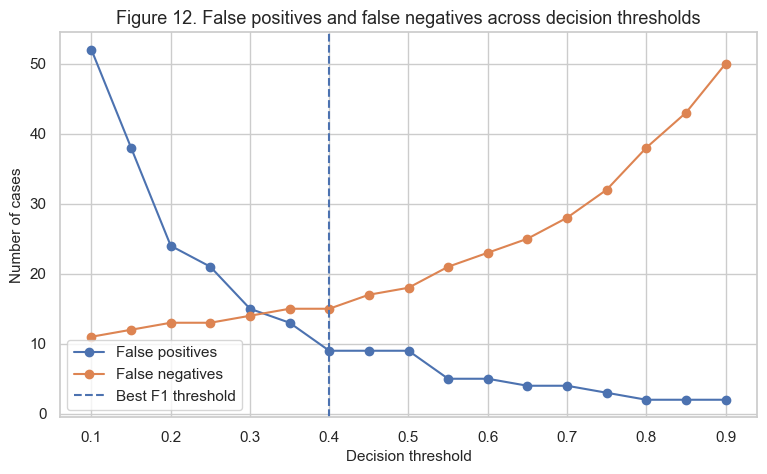

In [12]:
# I test different probability thresholds for practical maintenance decisions

from sklearn.metrics import precision_recall_curve

threshold_values = np.arange(0.10, 0.91, 0.05)

threshold_rows = []

for threshold in threshold_values:
    y_pred_threshold = (y_prob_final >= threshold).astype(int)
    
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "false_positives": confusion_matrix(y_test, y_pred_threshold).ravel()[1],
        "false_negatives": confusion_matrix(y_test, y_pred_threshold).ravel()[2],
        "true_positives": confusion_matrix(y_test, y_pred_threshold).ravel()[3]
    })

threshold_df = pd.DataFrame(threshold_rows)

print("Threshold performance table:")
display(threshold_df.round(4))

best_threshold_row = threshold_df.loc[threshold_df["f1_score"].idxmax()]

print("\nBest threshold based on F1-score:")
display(best_threshold_row.to_frame().T.round(4))

# Figure 11: Precision, recall and F1-score across thresholds
plt.figure(figsize=(9, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], marker="o", label="F1-score")
plt.axvline(best_threshold_row["threshold"], linestyle="--", label="Best F1 threshold")

plt.title("Figure 11. Precision, recall and F1-score across decision thresholds")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# Figure 12: False positives and false negatives across thresholds
plt.figure(figsize=(9, 5))
plt.plot(threshold_df["threshold"], threshold_df["false_positives"], marker="o", label="False positives")
plt.plot(threshold_df["threshold"], threshold_df["false_negatives"], marker="o", label="False negatives")
plt.axvline(best_threshold_row["threshold"], linestyle="--", label="Best F1 threshold")

plt.title("Figure 12. False positives and false negatives across decision thresholds")
plt.xlabel("Decision threshold")
plt.ylabel("Number of cases")
plt.legend()
plt.grid(True)
plt.show()

Final model:
Tuned Gradient Boosting

Selected decision threshold:
0.4

Classification report using threshold 0.40:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.85      0.78      0.82        68

    accuracy                           0.99      2000
   macro avg       0.92      0.89      0.90      2000
weighted avg       0.99      0.99      0.99      2000


Confusion matrix using threshold 0.40:
[[1923    9]
 [  15   53]]

Final threshold-adjusted performance:


,model,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
0,Tuned Gradient Boosting with 0.40 threshold,0.4,0.988,0.8548,0.7794,0.8154,0.9692,0.8066,1923,9,15,53


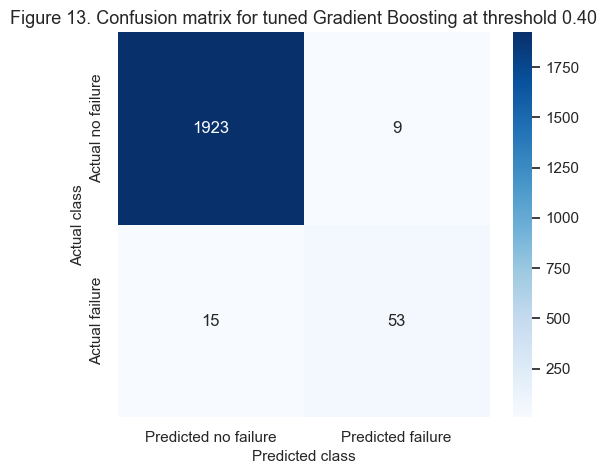

In [13]:
# I evaluate the final model using the selected 0.40 threshold

final_threshold = 0.40

y_pred_final_threshold = (y_prob_final >= final_threshold).astype(int)

print("Final model:")
print(final_model_name)

print("\nSelected decision threshold:")
print(final_threshold)

print("\nClassification report using threshold 0.40:")
print(classification_report(y_test, y_pred_final_threshold, zero_division=0))

cm_threshold = confusion_matrix(y_test, y_pred_final_threshold)
print("\nConfusion matrix using threshold 0.40:")
print(cm_threshold)

tn_t, fp_t, fn_t, tp_t = cm_threshold.ravel()

final_threshold_metrics = {
    "model": final_model_name + " with 0.40 threshold",
    "threshold": final_threshold,
    "accuracy": accuracy_score(y_test, y_pred_final_threshold),
    "precision": precision_score(y_test, y_pred_final_threshold, zero_division=0),
    "recall": recall_score(y_test, y_pred_final_threshold, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_final_threshold, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_final),
    "pr_auc": average_precision_score(y_test, y_prob_final),
    "true_negatives": tn_t,
    "false_positives": fp_t,
    "false_negatives": fn_t,
    "true_positives": tp_t
}

final_threshold_metrics_df = pd.DataFrame([final_threshold_metrics])

print("\nFinal threshold-adjusted performance:")
display(final_threshold_metrics_df.round(4))

# Figure 13: Final confusion matrix at threshold 0.40
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_threshold,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted no failure", "Predicted failure"],
    yticklabels=["Actual no failure", "Actual failure"]
)
plt.title("Figure 13. Confusion matrix for tuned Gradient Boosting at threshold 0.40")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()

In [14]:
# I prepare clean final tables for the report

# Table 1: Dataset overview
dataset_overview = pd.DataFrame({
    "Item": [
        "Dataset name",
        "Number of records",
        "Number of original columns",
        "Missing values",
        "Duplicate rows",
        "Target variable",
        "Problem type",
        "Failure class percentage"
    ],
    "Value": [
        "AI4I 2020 Predictive Maintenance Dataset",
        data.shape[0],
        data.shape[1],
        int(data.isna().sum().sum()),
        int(data.duplicated().sum()),
        "machine_failure",
        "Binary classification",
        f"{(y.mean() * 100):.2f}%"
    ]
})

print("Table 1. Dataset overview")
display(dataset_overview)


# Table 2: Feature description
feature_description = pd.DataFrame({
    "Feature": [
        "type",
        "air_temperature_k",
        "process_temperature_k",
        "rotational_speed_rpm",
        "torque_nm",
        "tool_wear_min",
        "machine_failure"
    ],
    "Description": [
        "Product quality category: L, M or H",
        "Air temperature measured in Kelvin",
        "Process temperature measured in Kelvin",
        "Rotational speed of the machine in rpm",
        "Torque applied by the machine in Newton metres",
        "Accumulated tool wear measured in minutes",
        "Binary target variable: 0 = no failure, 1 = failure"
    ],
    "Role in analysis": [
        "Input feature",
        "Input feature",
        "Input feature",
        "Input feature",
        "Input feature",
        "Input feature",
        "Target variable"
    ]
})

print("\nTable 2. Dataset feature description")
display(feature_description)


# Table 3: Target distribution
target_distribution_table = target_summary.copy()
target_distribution_table["class_label"] = target_distribution_table["machine_failure"].map({
    0: "No failure",
    1: "Failure"
})
target_distribution_table = target_distribution_table[
    ["machine_failure", "class_label", "count", "percentage"]
]

print("\nTable 3. Target variable distribution")
display(target_distribution_table)


# Table 4: Full model comparison
final_model_comparison_table = pd.concat(
    [all_results_df, final_threshold_metrics_df[
        ["model", "accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]
    ]],
    ignore_index=True
).sort_values(by="f1_score", ascending=False)

print("\nTable 4. Final model comparison")
display(final_model_comparison_table.round(4))


# Table 5: Final confusion matrix summary
final_confusion_summary = pd.DataFrame({
    "Outcome": [
        "True negatives",
        "False positives",
        "False negatives",
        "True positives"
    ],
    "Meaning": [
        "Correctly predicted non-failure records",
        "Non-failure records incorrectly predicted as failures",
        "Actual failures missed by the model",
        "Actual failures correctly detected by the model"
    ],
    "Count": [
        tn_t,
        fp_t,
        fn_t,
        tp_t
    ]
})

print("\nTable 5. Final confusion matrix summary")
display(final_confusion_summary)


# Table 6: Feature importance
final_feature_importance_table = feature_importance_df.copy()
final_feature_importance_table["rank"] = range(1, len(final_feature_importance_table) + 1)
final_feature_importance_table = final_feature_importance_table[
    ["rank", "feature", "importance", "importance_percent"]
]

print("\nTable 6. Feature importance summary")
display(final_feature_importance_table.round(4))

Table 1. Dataset overview


,Item,Value
0,Dataset name,AI4I 2020 Predictive Maintenance Dataset
1,Number of records,10000
2,Number of original columns,14
3,Missing values,0
4,Duplicate rows,0
5,Target variable,machine_failure
6,Problem type,Binary classification
7,Failure class percentage,3.39%



Table 2. Dataset feature description


,Feature,Description,Role in analysis
0,type,"Product quality category: L, M or H",Input feature
1,air_temperature_k,Air temperature measured in Kelvin,Input feature
2,process_temperature_k,Process temperature measured in Kelvin,Input feature
3,rotational_speed_rpm,Rotational speed of the machine in rpm,Input feature
4,torque_nm,Torque applied by the machine in Newton metres,Input feature
5,tool_wear_min,Accumulated tool wear measured in minutes,Input feature
6,machine_failure,"Binary target variable: 0 = no failure, 1 = fa...",Target variable



Table 3. Target variable distribution


...

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
10,Tuned Gradient Boosting with 0.40 threshold,0.9880,0.8548,0.7794,0.8154,0.9692,0.8066
0,Tuned Gradient Boosting,0.9865,0.8475,0.7353,0.7874,0.9692,0.8066
1,Gradient Boosting,0.9860,0.8846,0.6765,0.7667,0.9699,0.8022
2,Tuned Random Forest,0.9820,0.7857,0.6471,0.7097,0.9651,0.7708
3,Random Forest,0.9840,0.9286,0.5735,0.7091,0.9604,0.8069
4,Decision Tree,0.9780,0.6818,0.6618,0.6716,0.8254,0.4627
5,Balanced Decision Tree,0.9785,0.7119,0.6176,0.6614,0.8044,0.4527
6,Balanced Random Forest,0.9815,0.9189,0.5000,0.6476,0.9605,0.7963
7,Weighted Gradient Boosting,0.9335,0.3224,0.8676,0.4701,0.9653,0.6623
8,Balanced Logistic Regression,0.8245,0.1418,0.8235,0.2419,0.9069,0.3817



Table 5. Final confusion matrix summary


,Outcome,Meaning,Count
0,True negatives,Correctly predicted non-failure records,1923
1,False positives,Non-failure records incorrectly predicted as f...,9
2,False negatives,Actual failures missed by the model,15
3,True positives,Actual failures correctly detected by the model,53



Table 6. Feature importance summary


,rank,feature,importance,importance_percent
3,1,torque_nm,0.3873,38.73
4,2,tool_wear_min,0.1808,18.08
2,3,rotational_speed_rpm,0.1653,16.53
0,4,air_temperature_k,0.1402,14.02
1,5,process_temperature_k,0.1057,10.57
5,6,type_L,0.0173,1.73
6,7,type_M,0.0034,0.34


In [15]:
# I export final report tables so I can reuse them in the written report

import os

# I create an output folder for the project tables
output_folder = "ai4i_predictive_maintenance_outputs"
os.makedirs(output_folder, exist_ok=True)

# I save the main tables as CSV files
dataset_overview.to_csv(
    os.path.join(output_folder, "table_1_dataset_overview.csv"),
    index=False
)

feature_description.to_csv(
    os.path.join(output_folder, "table_2_feature_description.csv"),
    index=False
)

target_distribution_table.to_csv(
    os.path.join(output_folder, "table_3_target_distribution.csv"),
    index=False
)

final_model_comparison_table.to_csv(
    os.path.join(output_folder, "table_4_final_model_comparison.csv"),
    index=False
)

final_confusion_summary.to_csv(
    os.path.join(output_folder, "table_5_final_confusion_summary.csv"),
    index=False
)

final_feature_importance_table.to_csv(
    os.path.join(output_folder, "table_6_feature_importance.csv"),
    index=False
)

threshold_df.to_csv(
    os.path.join(output_folder, "threshold_analysis_table.csv"),
    index=False
)

print("Final tables exported successfully.")
print("Output folder:", output_folder)

print("\nFiles saved:")
for file in os.listdir(output_folder):
    print("-", file)

Final tables exported successfully.
Output folder: ai4i_predictive_maintenance_outputs

Files saved:
- table_1_dataset_overview.csv
- table_2_feature_description.csv
- table_3_target_distribution.csv
- table_4_final_model_comparison.csv
- table_5_final_confusion_summary.csv
- table_6_feature_importance.csv
- threshold_analysis_table.csv
